In [1]:
using Plots
using LinearAlgebra
using LaTeXStrings
# using FFTW
include("../fft.jl")
include("gratings.jl")
include("zoom.jl")
using Distributions: Poisson
using Random

In [2]:
function FT(y)
    return fftshift(fft(ifftshift(y)))
end

FT (generic function with 1 method)

In [344]:
function FC_matrix_setup(mill_depths, x_apex; 
						mode_blocking::Bool=true, γ::Real=0.008)

	g1 = blazed_grating_1d(N, p, x_apex; thickness=500, mill_depth=mill_depths[1])
	g2 = blazed_grating_1d(N, p, x_apex; thickness=500, mill_depth=mill_depths[2])

	g2_shift = -floor(Int, x_apex * ((N÷p)-1) ) - 2
    g2 = circshift(g2, g2_shift)
	
	t1 = transmission(g1;γ = γ)
	t3 = transmission(g2;γ = γ)
	

	t1st_fft = FT(t1)
	t3rd_fft = FT(t3)./N

	if mode_blocking
		t1st_fft[1:ctr-1] .= zero(eltype(t1st_fft))		
	end
	t1st_fft ./=sqrt(sum(abs2, t1st_fft))

	"""
		Because the t3_fft is normalized by N as apposed to ./=sqrt(sum(abs2, t1st_fft)), t3_fft
		is the fourier coefficents of t3 accounting for energy loss from scattering. Since t1_fft
		is normalized such that sum(abs2, t1_fft) == 1, we count that wavefunction in the normalized 
		input wave function that is transformed. So, t1_fft is not the fourier coefficients of t1
	"""
	return t1st_fft, t3rd_fft
end


function FC_matrix(Ms, mill_depths, x_apex; mode_blocking::Bool=true)

	c_t1, c_t3 = FC_matrix_setup(mill_depths, x_apex;
					 mode_blocking=mode_blocking, γ=0.008)

	sel = Ms .+ ctr
	idx = similar(sel)  # temporary index buffer to avoid allocations in the loop
	c_t1_sel = c_t1[sel]
	c_matrix = Matrix{eltype(c_t1)}(undef, length(Ms), length(Ms))
	@inbounds for (i,m) in enumerate(Ms)
		@. idx = sel + m
		# c_t3_shifted = circshift(c_t3, -m)
		c_matrix[i,:] = c_t3[idx] .* c_t1_sel 
	end
	return c_matrix
end

function FC_ψ_final(Ms, mill_depths, x_apex, phase_shift; mode_blocking::Bool=true)
	#the sample imparts a phase shift to the +1 order of the first grating
	c_matrix = FC_matrix(Ms, mill_depths, x_apex; mode_blocking=mode_blocking)
	σU = π/21
	γ = 0.008
	d = phase_shift/σU
	k=1 
	c_matrix[:, length(Ms)÷2 + 1 + k] .*= cis((σU + γ*im)d)
	return abs2.(sum(c_matrix, dims=2))
end

FC_ψ_final (generic function with 1 method)

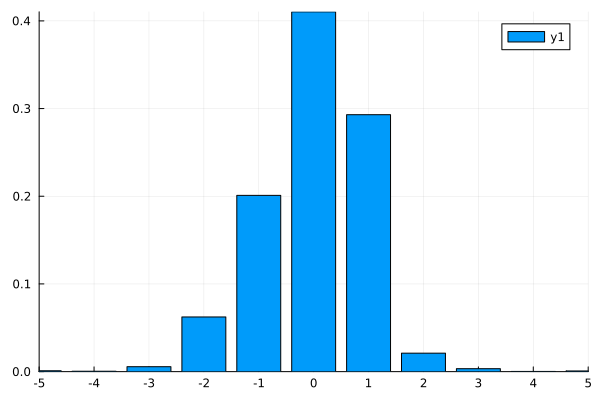

In [345]:
N = 2^5
ctr = N ÷ 2 + 1
p = 1
x_apex = 0.6
mill_depths = [80, 120]
t = transmission(blazed_grating_1d(N, p, x_apex); γ=0)
t_fft = FT(t)./N
modes = collect(-5:5)
y_plot = abs2.(copy(t_fft)[ctr .+ modes])
bar(modes, y_plot;
    xticks = (modes, modes)
)
xlims!(-5,5)

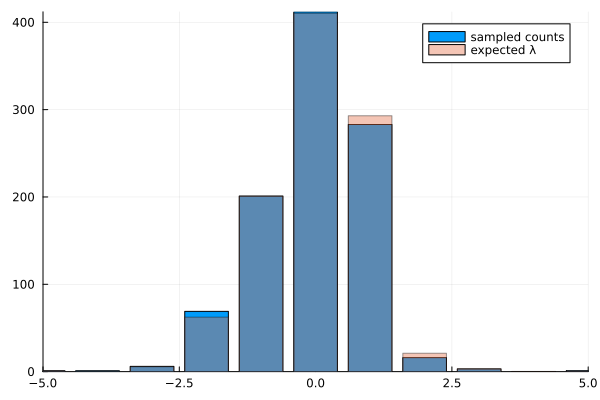

In [346]:
# simulate Poisson counts for N_electrons
N_electrons = 1_000          # set total electrons
λ = N_electrons .* y_plot       # expected counts per bin

Random.seed!(1234)                # optional reproducibility
counts= rand.(Poisson.(λ))       # Poisson draw per bin
# plot expected vs sampled
bar(modes, counts, label="sampled counts")
bar!(modes, λ, alpha=0.4, label="expected λ")
xlims!(-5,5)   

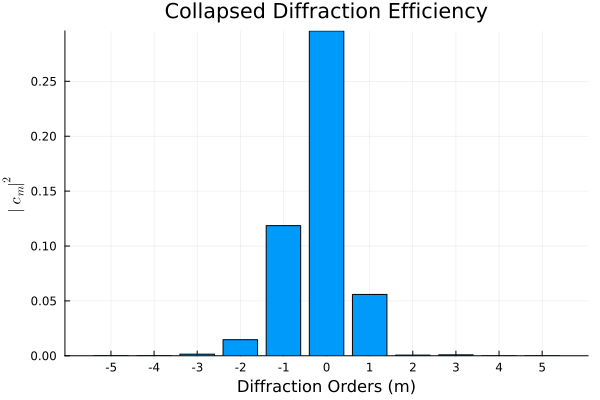

In [414]:
c_matrix = FC_matrix(modes, [80.0, 120.0], x_apex; mode_blocking=true);
println(sum(abs2,(sum(c_matrix, dims=2))));
c_collapsed = FC_ψ_final(modes, [80.0, 120.0], x_apex, π; mode_blocking=true);
println(size(c_collapsed));
heatmap(modes,modes, log1p.(abs.(c_matrix)), 
    xticks = (modes, modes),
    yticks = (modes, modes),
    title="Fourier Coefficient Matrix", colorbar_title=""
    )
bar(modes, c_collapsed, 
    xticks = (modes, modes),
    xlabel="Diffraction Orders (m)", 
    ylabel=L"|c_m|^2", 
    title="Collapsed Diffraction Efficiency", 
    legend=false
    )

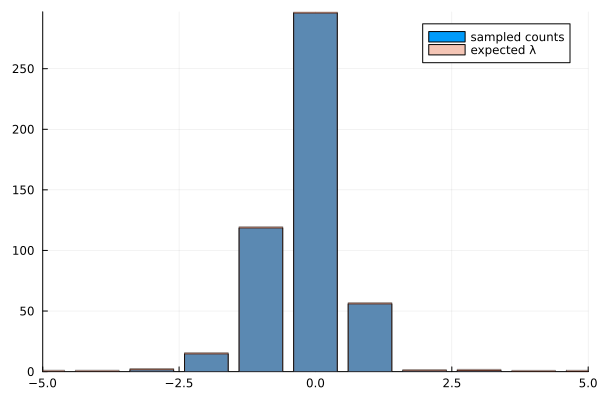

In [721]:
# simulate Poisson counts for N_electrons
N_electrons = 1_000          # set total electrons
N_ratio = 1e-3
λ_collapsed = @. N_electrons * (c_collapsed + N_ratio)    # expected counts per bin

# Random.seed!(1234)                # optional reproducibility
counts_mean = N_electrons .* c_collapsed
counts_collapsed = @. N_electrons*(c_collapsed + N_ratio)   # Poisson draw per bin
# counts_collapsed = rand.(Poisson.(λ_collapsed))       # Poisson draw per bin
# plot expected vs sampled
bar(modes, counts_mean, label="sampled counts")
bar!(modes, counts_collapsed, alpha=0.4, label="expected λ")
xlims!(-5,5)   

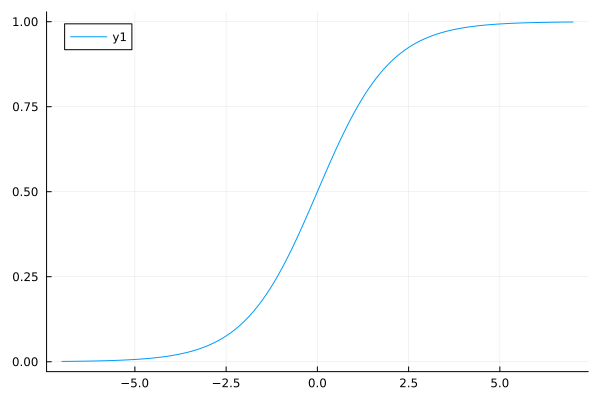

In [722]:
logistic(x) = 1 / (1 + exp(-x))
z = -7:0.1:7
plot(z,logistic.(z))

In [723]:
using Turing
@model function grating_model(y_data, N_electrons)
    x_apex_mcmc ~ Uniform(0.0, 1.0)
    
    t_mcmc = transmission(blazed_grating_1d(N, 1, x_apex_mcmc))
    t_fft_mcmc = FT(t_mcmc)./N
    y_mcmc = abs2.(copy(t_fft_mcmc)[ctr .+ modes])
    λ_mcmc = N_electrons .* y_mcmc
    for i in eachindex(y_data)
        y_data[i] ~ Poisson(λ_mcmc[i])  
    end

end
chain = sample(grating_model(counts, N_electrons), NUTS(0.65), 1_000)

Chains MCMC chain (1000×13×1 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 27.54 seconds
Compute duration  = 27.54 seconds
parameters        = x_apex_mcmc
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
   parameters      mean       std      mcse   ess_bulk   ess_tail      rhat    ⋯
       Symbol   Float64   Float64   Float64    Float64    Float64   Float64    ⋯

  x_apex_mcmc    0.5979    0.0103    0.0005   430.2432   426.5789    0.9996    ⋯
                                                                1 column omitted

Quantiles
   parameters      2.5%     25.0%     50.0%     75.0%     97.5% 
       Symbol   Float64   Float64   Float64   Float64   Float64 

  x_apex_mcmc    0.5815    0.5892    0.5983    0.6066    0.6126


In [724]:
using Turing
using StatsPlots
@model function grating_model(y_data, N_electrons)
    
    ϕ_mcmc_scaled ~ Uniform(-1.0, 1.0)
    x_apex_mcmc_scaled ~ Uniform(0.0, 1.0)
    mill_depth_1_scaled ~ Uniform(0.0, 1.0)
    mill_depth_2_scaled ~ Uniform(0.0, 1.0)

    ϕ_mcmc = logistic.(5*ϕ_mcmc_scaled) * 2π
    mill_depth_1 = mill_depth_1_scaled * 200.0
    mill_depth_2 = mill_depth_2_scaled * 200.0
    x_apex_mcmc = x_apex_mcmc_scaled


    c_collapsed_mcmc = FC_ψ_final(modes, [mill_depth_1, mill_depth_2], x_apex_mcmc, ϕ_mcmc; mode_blocking=true); 
    
    λ_mcmc = @. N_electrons * (c_collapsed_mcmc + N_ratio)
    for i in eachindex(y_data)
        # y_data[i] ~ Poisson(λ_mcmc[i]) 
        Turing.@addlogprob! y_data[i] * log(λ_mcmc[i]) - λ_mcmc[i]
        # Turing.@addlogprob! data[i]log(model[i]) - model[i] #poissonian 
    end

end


grating_model (generic function with 2 methods)

In [725]:
n_samples = 1000
n_chains = 4
# chain = sample(grating_model(counts_collapsed, N_electrons),
#                NUTS(0.65),
#                MCMCThreads(),
#                n_samples,
#                n_chains;
#                save_state=true)
chain_basic = sample(grating_model(counts_collapsed, N_electrons),
               NUTS(0.65),
               n_samples;
               save_state=true)

Chains MCMC chain (1000×16×1 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 54.51 seconds
Compute duration  = 54.51 seconds
parameters        = ϕ_mcmc_scaled, x_apex_mcmc_scaled, mill_depth_1_scaled, mill_depth_2_scaled
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
           parameters      mean       std      mcse   ess_bulk   ess_tail      ⋯
               Symbol   Float64   Float64   Float64    Float64    Float64   Fl ⋯

        ϕ_mcmc_scaled   -0.0713    0.1148    0.0128    85.8873    62.6786    1 ⋯
   x_apex_mcmc_scaled    0.6200    0.0663    0.0039   280.2421   365.5488    1 ⋯
  mill_depth_1_scaled    0.4932    0.1349    0.0173    78.3641    78.2493    1 ⋯
  mill_depth_2_scaled    0.6042    0.0419    0.0030   201.4704   158.7110    1

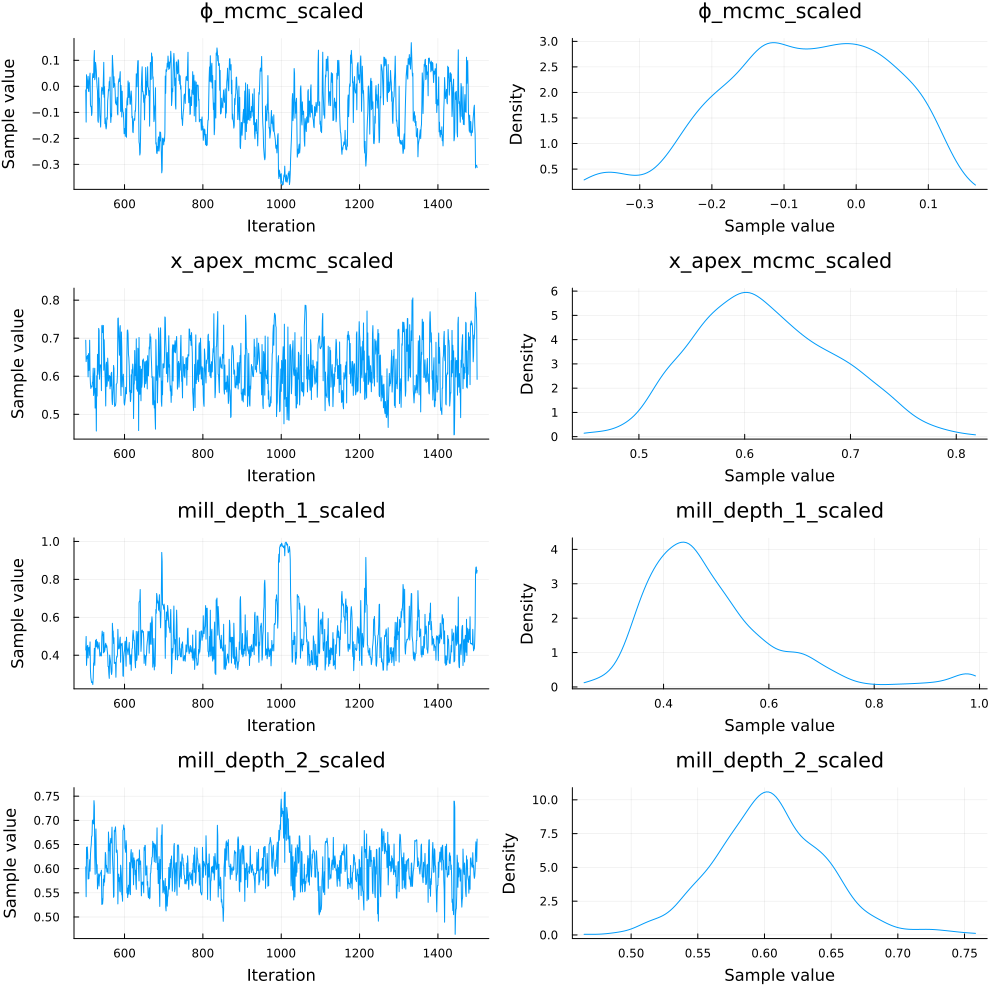

In [726]:
plot(chain_basic)

In [727]:
using PairPlots
using GLMakie
params = [:ϕ_mcmc_scaled,:x_apex_mcmc_scaled, :mill_depth_1_scaled, :mill_depth_2_scaled]
pairplot(chain_basic[:,params,1]
)


In [728]:

# inv_mass_metric = chain_basic.info.hamiltonian
println(dump(chain_basic.info.samplerstate.hamiltonian.metric.M⁻¹))

In [729]:
using AdvancedHMC
δ_target = 0.65
ϵ0 = 0.9
D = 4
metric = DenseEuclideanMetric(D)
# kernel = HMCKernel(Trajectory{MultinomialTS}(Leapfrog(ϵ0), ClassicNoUTurn(max_depth=7)))
kernel = HMCKernel(Trajectory{MultinomialTS}(Leapfrog(ϵ0), GeneralisedNoUTurn(max_depth=9)))
mma = MassMatrixAdaptor(metric)
ssa = StepSizeAdaptor(δ_target, Leapfrog(ϵ0))
adaptor = StanHMCAdaptor(mma, ssa)
hmcsampler = AdvancedHMC.HMCSampler(kernel, metric, adaptor)  
nuts_custom = externalsampler(hmcsampler)
nuts_custom = externalsampler(AdvancedHMC.NUTS(δ_target; metric=:dense))

Turing.Inference.ExternalSampler{AdvancedHMC.NUTS{Float64, Symbol, Symbol}, AutoForwardDiff{nothing, Nothing}, true}(AdvancedHMC.NUTS{Float64, Symbol, Symbol}(0.65, 10, 1000.0, :leapfrog, :dense), AutoForwardDiff())

In [730]:
n_adapts = 5_000
chain = sample(grating_model(counts_collapsed, N_electrons),
               nuts_custom,    #metric = DenseEuclideanMetric(D),
               n_samples+5_000;
               n_adapts=n_adapts,
               save_state=true)

Chains MCMC chain (6000×17×1 Array{Float64, 3}):

Iterations        = 1:1:6000
Number of chains  = 1
Samples per chain = 6000
Wall duration     = 233.95 seconds
Compute duration  = 233.95 seconds
parameters        = ϕ_mcmc_scaled, x_apex_mcmc_scaled, mill_depth_1_scaled, mill_depth_2_scaled
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, is_adapt

Summary Statistics
           parameters      mean       std      mcse    ess_bulk    ess_tail    ⋯
               Symbol   Float64   Float64   Float64     Float64     Float64    ⋯

        ϕ_mcmc_scaled   -0.0773    0.1159    0.0056    427.0854    341.0802    ⋯
   x_apex_mcmc_scaled    0.6186    0.0721    0.0022   1054.4489   1448.4783    ⋯
  mill_depth_1_scaled    0.4970    0.1385    0.0070    557.2900    346.8479    ⋯
  mill_depth_2_scaled    0.6042    0.0428    0.0014   1002.9802   11

In [731]:
println("size: ", size(chain))          # shows (iterations, n_vars, n_chains)
println("nchains: ", length(chains(chain)))
println("variable names: ", names(chain))   # lists all 17 names

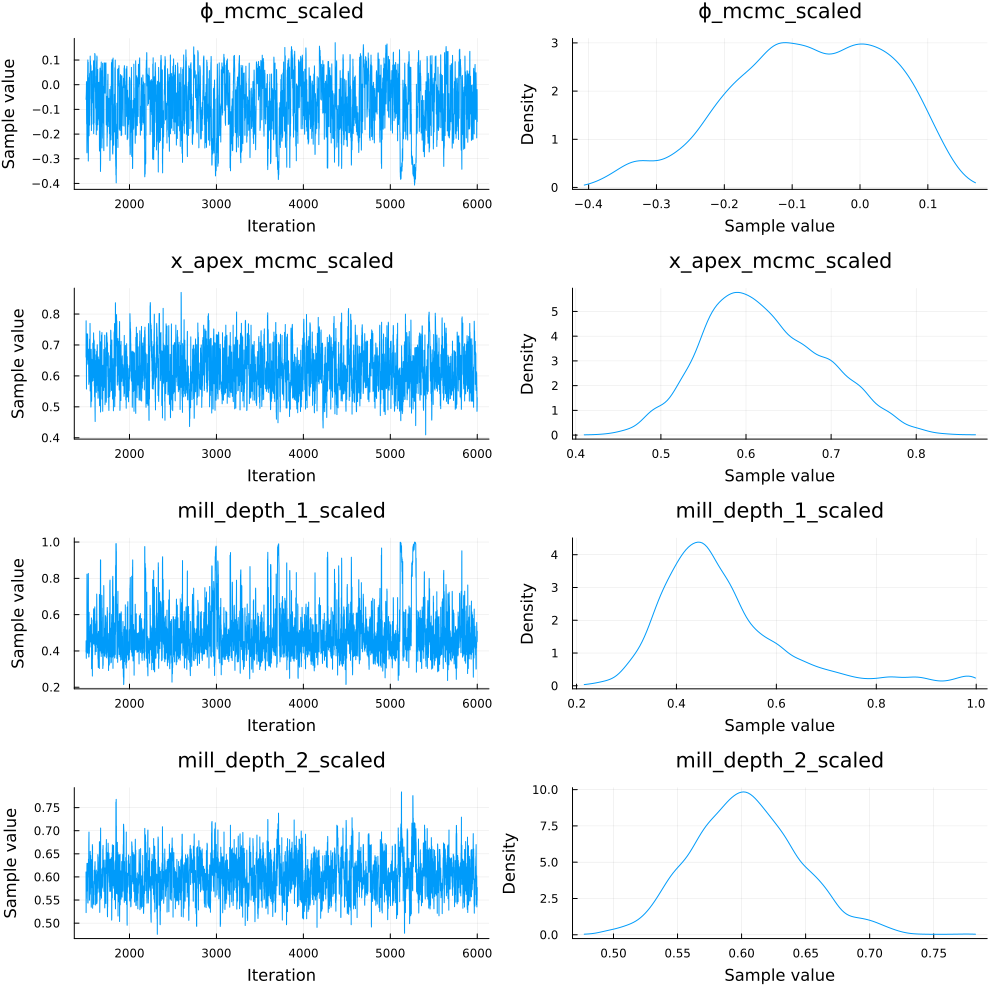

In [738]:
println(size(chain))
plot(chain[1500:end,:,1])

In [733]:
x_apexes = collect(0.58:0.01:0.62)
shift_func(input) = -floor(Int, input * ((N÷p)-1) ) - 2
shift_func.(x_apexes)

5-element Vector{Int64}:
 -19
 -20
 -20
 -20
 -21

In [740]:
using PairPlots
using GLMakie
labels = Dict(
  :ϕ_mcmc_scaled => "phase_shift",
  :x_apex_mcmc_scaled => "x_apex",
  :mill_depth_1_scaled => "mill_depth_1",
  :mill_depth_2_scaled => "mill_depth_2",
)
pairplot(chain[1000:end,params,1],
    labels = labels
)

4×4 Matrix{Float64}:
  0.0520807   -0.00397057  -0.0823427  -0.00688961
 -0.00397057   0.0967242    0.0322843  -0.0190023
 -0.0823427    0.0322843    0.42493     0.0147504
 -0.00688961  -0.0190023    0.0147504   0.0307998

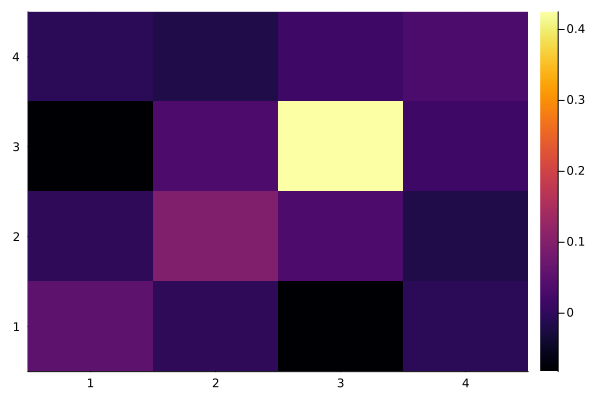

In [735]:
inv_mass_metric = chain.info.samplerstate.state.metric.M⁻¹
display(inv_mass_metric)
heatmap(inv_mass_metric)


In [736]:
println("mean is_accept = ", mean(vec(Array(chain[:, :is_accept, :]))))
println("mean acceptance_rate = ", mean(vec(Array(chain[:, :acceptance_rate, :]))))
println("step_size unique = ", unique(vec(Array(chain[:, :step_size, :]))))
println("lp min,max = ", minimum(vec(Array(chain[:, :lp, :]))), ", ", maximum(vec(Array(chain[:, :lp, :]))))
for name in (:x_apex_mcmc_scaled, :mill_depth_1_scaled, :mill_depth_2_scaled, :ϕ_mcmc_scaled)
    vals = vec(Array(chain[:, name, :]))
    println(name, ": unique=", length(unique(vals)), " min=", minimum(vals), " max=", maximum(vals))
end

In [737]:
# check what metric object is stored
println(typeof(chain.info.samplerstate.state.metric))
# print the stored metric (and inverse) explicitly
display(chain.info.samplerstate.state.metric)
display(chain.info.samplerstate.state.metric.M⁻¹)

# check iteration range to see if warmup happened (start != 1 implies warmup used)
println("iterations: ", axes(chain.value,1))

DenseEuclideanMetric(diag=[0.05208068819666503, 0.096 ...])

4×4 Matrix{Float64}:
  0.0520807   -0.00397057  -0.0823427  -0.00688961
 -0.00397057   0.0967242    0.0322843  -0.0190023
 -0.0823427    0.0322843    0.42493     0.0147504
 -0.00688961  -0.0190023    0.0147504   0.0307998

In [7]:
atan(0.008,π/21)

0.053425173194915944